<a href="https://colab.research.google.com/github/Jessica1842553/MCDpycd2026/blob/main/Tarea5_PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tarea 5 - Análisis de Imágenes
### Jessica Lizeth Hernández Bracho - 1842553

### 1. Carga de Dependencias y Simulación del Dataset

In [1]:
!pip install --upgrade protobuf tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.35.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# Carga del conjunto de datos
dataset, info = tfds.load('malaria', with_info=True, as_supervised=True)

train_dataset = dataset['train'].take(400)
test_dataset = dataset['train'].skip(400).take(100)

Muestras listas para procesar.


### 2. Preprocesamiento y Visualización

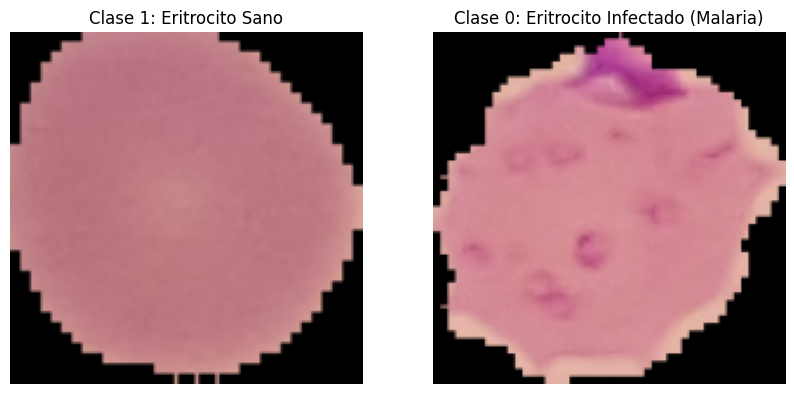

In [2]:
def preprocess(image, label):
    image = tf.image.resize(image, (150, 150))

    image = image / 255.0
    return image, label

# Mapeo
train_dataset = train_dataset.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

# Extracción limpia para ejemplo
img_infect, img_sana = None, None
for img_raw, lbl_raw in dataset['train'].take(100):
    if lbl_raw.numpy() == 0 and img_infect is None:
        img_infect = tf.image.resize(img_raw, (150, 150)) / 255.0
    elif lbl_raw.numpy() == 1 and img_sana is None:
        img_sana = tf.image.resize(img_raw, (150, 150)) / 255.0
    if img_infect is not None and img_sana is not None:
        break

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_sana)
plt.title("Clase 1: Eritrocito Sano")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_infect)
plt.title("Clase 0: Eritrocito Infectado (Malaria)")
plt.axis('off')
plt.show()

### 3. Carga del Modelo Base y Estrategia de Fine-Tuning

In [3]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

# Congelamos el modelo base por completo
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Clasificación binaria (Sana vs Infectada)
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 4. Compilación y Entrenamiento

In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Resumen de la red
model.summary()

# Entrenamiento de 10 épocas
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 135s 10s/step - accuracy: 0.5275 - loss: 1.0834 - val_accuracy: 0.5700 - val_loss: 0.6883
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 143s 11s/step - accuracy: 0.7750 - loss: 0.4770 - val_accuracy: 0.7800 - val_loss: 0.4852
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 151s 12s/step - accuracy: 0.8650 - loss: 0.3258 - val_accuracy: 0.7600 - val_loss: 0.4337
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 143s 11s/step - accuracy: 0.9200 - loss: 0.2578 - val_accuracy: 0.7400 - val_loss: 0.4179
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 145s 11s/step - accuracy: 0.9425 - loss: 0.2205 - val_accuracy: 0.7500 - val_loss: 0.4171
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 128s 10s/step - accuracy: 0.9475 - loss: 0.1977 - val_accuracy: 0.7400 - val_loss: 0.4350
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 152s 12s/step - accuracy: 0.9450 - loss: 0.1816 - val_accuracy: 0.7400 - val_loss: 0.4507
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 143s 11s/step - accuracy: 0.9400 - loss: 0.1690 - val_accuracy: 0.

### 5. Despliegue de Gráficas de Resultados

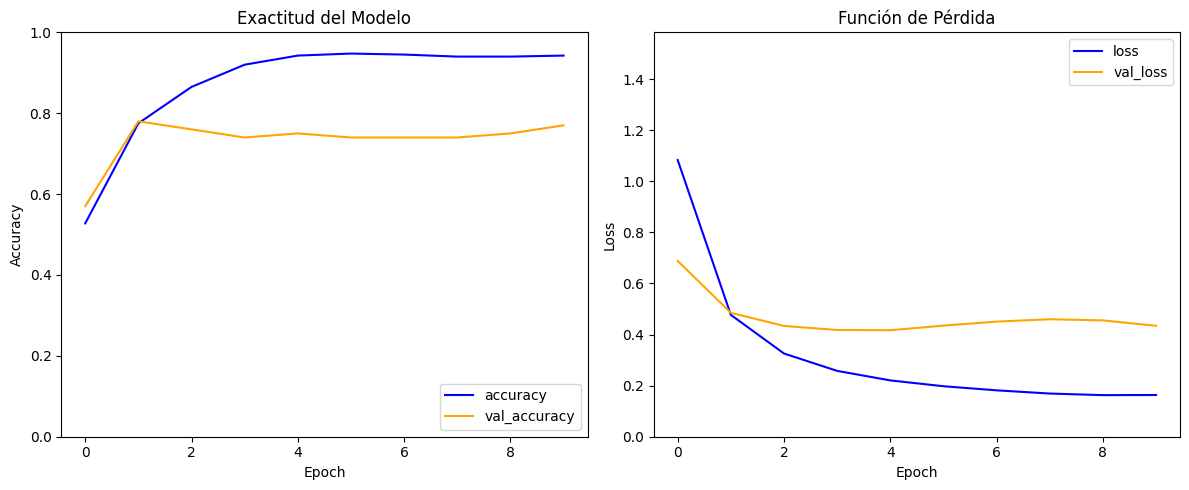

In [5]:
plt.figure(figsize=(12, 5))

# Gráfica de Exactitud (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='val_accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Exactitud del Modelo')

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss', color='blue')
plt.plot(history.history['val_loss'], label='val_loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, max(history.history['loss']) + 0.5])
plt.legend(loc='upper right')
plt.title('Función de Pérdida')

plt.tight_layout()
plt.show()